In [ ]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError("❌ No se detectó GPU. Cambia el runtime a GPU.")

gpu_name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"✅ GPU: {gpu_name} | VRAM: {vram_gb:.1f} GB")



✅ GPU: NVIDIA A100-SXM4-40GB | VRAM: 42.4 GB


In [ ]:
!pip install -U transformers datasets accelerate peft trl bitsandbytes tensorboard scikit-learn sentencepiece protobuf


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Rutas en Drive
DRIVE_BASE = "/content/drive/MyDrive/sec_project"
MODEL_OUT   = f"{DRIVE_BASE}/models/llama3b_lora"
REPORTS_DIR = f"{DRIVE_BASE}/reports"

os.makedirs(MODEL_OUT, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
print(f"✅ Modelo se guardará en: {MODEL_OUT}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Modelo se guardará en: /content/drive/MyDrive/sec_project/models/llama3b_lora


In [ ]:
from google.colab import files
import shutil

# Opción A: Subir desde tu máquina local
#print("📁 Sube train.jsonl y val.jsonl")
#uploaded = files.upload()

# Opción B: Si ya los tienes en Drive del paso anterior, comenta lo de arriba y usa:
 #shutil.copy(f"{DRIVE_BASE}/data/train.jsonl", "/content/train.jsonl")
 #shutil.copy(f"{DRIVE_BASE}/data/val.jsonl", "/content/val.jsonl")


In [ ]:
from datasets import load_dataset

dataset = load_dataset("json", data_files={
    "train": "/content/train.jsonl",
    "val":   "/content/val.jsonl"
})

print(f"✅ Train: {len(dataset['train'])} ejemplos")
print(f"✅ Val:   {len(dataset['val'])} ejemplos")
print(f"📋 Columnas: {dataset['train'].column_names}")
print(f"📋 Ejemplo:\n{dataset['train'][0]}")


✅ Train: 10147 ejemplos
✅ Val:   1791 ejemplos
📋 Columnas: ['instruction', 'input', 'output']
📋 Ejemplo:
{'instruction': 'Summarize the revenue performance described in the following SEC filing excerpt.', 'input': "s moving beyond 2D screens toward immersive experiences like augmented and virtual reality to help build the metaverse, which we believe is the next evolution in social technology.\nWe report financial results for two segments: Family of Apps (FoA) and Reality Labs (RL). For FoA, we generate substantially all of our revenue from selling advertising placements to marketers. Ads on our platforms enable marketers to reach people based on a variety of factors including age, gender, location, interests, and behaviors. Marketers purchase ads that can appear in multiple places including on Facebook, Instagram, Messenger, and third-party applications and websites. RL generates revenue from sales of consumer hardware products, software and content. Our products include: \nFamily of A

In [ ]:
from huggingface_hub import login
login()  # Ingresa tu token de HuggingFace

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import get_peft_model, LoraConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

MODEL_ID = "meta-llama/Llama-3.2-3B-Instruct"

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, force_download=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Modelo en FP16 (LoRA estándar, sin cuantización)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    force_download=True,
)
model.config.pad_token_id = tokenizer.pad_token_id

# Info del modelo
total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Modelo cargado: {MODEL_ID}")
print(f"📊 Parámetros totales: {total_params / 1e9:.2f}B")
print(f"💾 VRAM usada: {torch.cuda.memory_allocated() / 1e9:.2f} GB")


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

✅ Modelo cargado: meta-llama/Llama-3.2-3B-Instruct
📊 Parámetros totales: 1.80B
💾 VRAM usada: 2.37 GB


In [ ]:

# 3. Aplica LoRA
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_config)

In [ ]:
MAX_SEQ_LEN = 1024

SYSTEM_PROMPT = (
    "You are a senior financial analyst assistant specialized in SEC filings. "
    "Answer accurately and concisely based on the provided context from 10-K and 10-Q reports."
)

def format_prompt(example):
    """Aplica el chat template de Llama-3.2-Instruct."""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": example["instruction"]},
        {"role": "assistant", "content": example["output"]},
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    )
    return {"text": text}

# Aplicar formato
formatted = dataset.map(format_prompt, remove_columns=dataset["train"].column_names)

print(f"✅ Ejemplo formateado:\n{formatted['train'][0]['text'][:500]}...")


✅ Ejemplo formateado:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 21 Aug 2026

You are a senior financial analyst assistant specialized in SEC filings. Answer accurately and concisely based on the provided context from 10-K and 10-Q reports.<|eot_id|><|start_header_id|>user<|end_header_id|>

Summarize the revenue performance described in the following SEC filing excerpt.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

<|eot_id|>...


In [ ]:
def tokenize_fn(examples):
    tokens = tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_SEQ_LEN,
        padding="max_length",
    )
    # ✅ FIX: Reemplazar pad_token_id con -100 en labels
    labels = []
    for ids in tokens["input_ids"]:
        label = [
            token_id if token_id != tokenizer.pad_token_id else -100
            for token_id in ids
        ]
        labels.append(label)

    tokens["labels"] = labels
    return tokens

tokenized = formatted.map(tokenize_fn, batched=True, remove_columns=["text"], load_from_cache_file=False)
tokenized.set_format("torch")

# Verificación rápida
sample_labels = tokenized["train"][0]["labels"]
n_ignored = (sample_labels == -100).sum().item()
n_active  = (sample_labels != -100).sum().item()
print(f"✅ Tokenización corregida")
print(f"📊 Ejemplo — tokens activos: {n_active} | ignorados (padding): {n_ignored}")



Map:   0%|          | 0/10147 [00:00<?, ? examples/s]

Map:   0%|          | 0/1791 [00:00<?, ? examples/s]

✅ Tokenización corregida
📊 Ejemplo — tokens activos: 81 | ignorados (padding): 943


In [ ]:
import inspect
from transformers import TrainingArguments

# Calcular pasos
EPOCHS = 3
BATCH_SIZE = 2       # LoRA usa menos VRAM → podemos subir el batch
GRAD_ACCUM = 8       # Effective batch size = 2 * 8 = 16
LEARNING_RATE = 2e-4  # LoRA tolera LR más altos que full FT

total_steps = (len(tokenized["train"]) // (BATCH_SIZE * GRAD_ACCUM)) * EPOCHS
warmup_steps = int(total_steps * 0.05)

print(f"📊 Total steps: {total_steps} | Warmup: {warmup_steps}")

# Verificar parámetros disponibles
valid_params = set(inspect.signature(TrainingArguments.__init__).parameters.keys())

training_args_dict = {
    "output_dir": "/content/lora_checkpoints",
    "num_train_epochs": EPOCHS,
    "per_device_train_batch_size": BATCH_SIZE,
    "per_device_eval_batch_size": BATCH_SIZE,
    "gradient_accumulation_steps": GRAD_ACCUM,
    "learning_rate": LEARNING_RATE,
    "warmup_steps": warmup_steps,
    "weight_decay": 0.01,
    "bf16": True,
    "gradient_checkpointing": True,
    "eval_strategy": "steps",
    "eval_steps": 50,
    "save_strategy": "steps",
    "save_steps": 200,
    "save_total_limit": 2,
    "save_only_model": True,
    "load_best_model_at_end": True,
    "metric_for_best_model": "eval_loss",
    "greater_is_better": False,
    "report_to": "tensorboard",
    "lr_scheduler_type": "cosine",
    "optim": "adamw_torch",
    "logging_steps": 10,
}

# Filtrar solo parámetros válidos
training_args_dict = {k: v for k, v in training_args_dict.items() if k in valid_params}
training_args = TrainingArguments(**training_args_dict)

print("✅ TrainingArguments configurados correctamente")


📊 Total steps: 1902 | Warmup: 95
✅ TrainingArguments configurados correctamente


In [ ]:
from transformers import Trainer, DataCollatorForLanguageModeling, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["val"],
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
)

print("🚀 Iniciando entrenamiento LoRA...")
train_result = trainer.train()
print("✅ Entrenamiento completado!")


🚀 Iniciando entrenamiento LoRA...


Step,Training Loss,Validation Loss
50,0.496984,0.395708
100,0.325877,0.325550
150,0.176793,0.114810
200,0.041194,0.040070
250,0.041414,0.038811
300,0.039716,0.039749
350,0.039327,0.038787
400,0.038835,0.039076
450,0.038726,0.038723
500,0.041514,0.039333


Step,Training Loss,Validation Loss
50,0.496984,0.395708
100,0.325877,0.325550
150,0.176793,0.114810
200,0.041194,0.040070
250,0.041414,0.038811
300,0.039716,0.039749
350,0.039327,0.038787
400,0.038835,0.039076
450,0.038726,0.038723
500,0.041514,0.039333


✅ Entrenamiento completado!


In [ ]:
import json

# Guardar adaptador LoRA (solo pesa ~50-100 MB)
model.save_pretrained(MODEL_OUT)
tokenizer.save_pretrained(MODEL_OUT)
print(f"✅ Adaptador LoRA guardado en: {MODEL_OUT}")

# Métricas
train_metrics = train_result.metrics
eval_metrics = trainer.evaluate()

summary = {
    "model": MODEL_ID,
    "method": "LoRA",
    "lora_r": 16,
    "lora_alpha": 32,
    "target_modules": lora_config.target_modules,
    "trainable_params": sum(p.numel() for p in model.parameters() if p.requires_grad),
    "total_params": sum(p.numel() for p in model.parameters()),
    "train_loss": train_metrics.get("train_loss"),
    "eval_loss": eval_metrics.get("eval_loss"),
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "effective_batch_size": BATCH_SIZE * GRAD_ACCUM,
    "max_seq_len": MAX_SEQ_LEN,
}

def convert_sets(obj):
    if isinstance(obj, set):
        return list(obj)
    if isinstance(obj, dict):
        return {k: convert_sets(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [convert_sets(i) for i in obj]
    return obj

summary = convert_sets(summary)

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

summary_path = f"{REPORTS_DIR}/llama3b_lora_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"📄 Resumen guardado en: {summary_path}")
print(json.dumps(summary, indent=2))


✅ Adaptador LoRA guardado en: /content/drive/MyDrive/sec_project/models/llama3b_lora


Training Loss,Validation Loss,Step
0.038875,0.038412,1750


📄 Resumen guardado en: /content/drive/MyDrive/sec_project/reports/llama3b_lora_summary.json
{
  "model": "meta-llama/Llama-3.2-3B-Instruct",
  "method": "LoRA",
  "lora_r": 16,
  "lora_alpha": 32,
  "target_modules": [
    "v_proj",
    "q_proj",
    "k_proj",
    "o_proj"
  ],
  "trainable_params": 9175040,
  "total_params": 1812638720,
  "train_loss": 0.12802209963117328,
  "eval_loss": 0.03841179981827736,
  "epochs": 3,
  "learning_rate": 0.0002,
  "effective_batch_size": 16,
  "max_seq_len": 1024
}


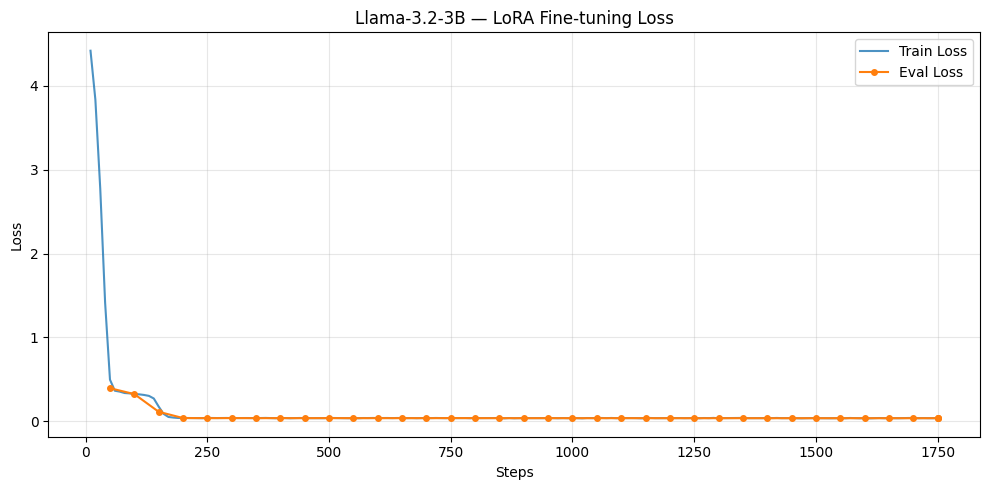

📊 Gráfica guardada en: /content/drive/MyDrive/sec_project/reports/llama3b_lora_loss.png


In [ ]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps = [x["step"] for x in log_history if "loss" in x]
train_loss  = [x["loss"] for x in log_history if "loss" in x]

eval_steps = [x["step"] for x in log_history if "eval_loss" in x]
eval_loss  = [x["eval_loss"] for x in log_history if "eval_loss" in x]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss, label="Train Loss", alpha=0.8)
plt.plot(eval_steps, eval_loss, label="Eval Loss", marker="o", markersize=4)
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Llama-3.2-3B — LoRA Fine-tuning Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plot_path = f"{REPORTS_DIR}/llama3b_lora_loss.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"📊 Gráfica guardada en: {plot_path}")


In [ ]:
from peft import PeftModel

# El modelo ya está en memoria con el adaptador, pero si necesitas recargarlo:
# base_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float16, device_map="auto")
# model = PeftModel.from_pretrained(base_model, MODEL_OUT)

model.eval()

# ── 4. Preguntas de prueba ──
test_questions = [
    "What are the main risk factors disclosed in a typical 10-K filing?",
    "Summarize the key components of an SEC annual report.",
    "What is the difference between a 10-K and a 10-Q filing?",
]

for q in test_questions:
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": q},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=256,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
        )

    response = tokenizer.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

    print(f"\n{'='*60}")
    print(f"❓ {q}")
    print(f"💬 {response}")



❓ What are the main risk factors disclosed in a typical 10-K filing?
💬 In a typical 10-K filing, the main risk factors disclosed by a company are:

1. **Liquidity risk**: The company's ability to meet its short-term obligations, such as accounts payable and accounts receivable.
2. **Credit risk**: The risk of not meeting obligations due to credit issues, such as default on debt or credit lines.
3. **Market risk**: The risk of losses due to market fluctuations, such as changes in interest rates, stock prices, or foreign exchange rates.
4. **Operational risk**: The risk of losses due to internal or external factors, such as operational errors, system failures, or regulatory changes.
5. **Leverage risk**: The risk of excessive debt and its impact on the company's financial health.
6. **Regulatory risk**: The risk of non-compliance with laws, regulations, and standards, such as SEC filings, tax laws, or industry-specific regulations.
7. **Concentration of credit risk**: The risk of signif